<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Relatividad-y-gravitacion/PS8_DerivadaCovariante_RG_2024_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Relatividad y Gravitación</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Problem Set 8</center></b><h2>
<h3><b><center>Derivada Covariante</center></b><h3>
<h5><center><b>Asignada</b>: Jueves 7 de Noviembre de 2024</center><h5>
<h5><center><b>Entrega</b>: Jueves 14 de Noviembre de 2024</center><h5>
<small><center><i>Última actualización del profesor</i>: Viernes 8 de Noviembre de 2024, 13:30</center></small>

juan manuel cardenas

**NOTA**: Al inicio de la solución entregada debe incluir una relación de los puntos y los literales que resolvió completamente.

> *completo totalmente*

___

A continuación se presentan un conjunto de ejercicios o problemas para resolver usando la teoría vista en las últimas lecciones del curso. Resuelva los ejercicios *a mano* y suba una versión digitalizada en el espacio del ítem respectivo en Google Classroom.

**NOTA**: Los ejercicios marcados como **[Numérico]** deben resolverse exclusivamente usando las herramientas numéricas vistas en el curso, incluso si tienen una solución que puede obtenerse de forma enteramente analítica. El objetivo es que se aprendan a utilizar esas herramientas.

1. **Corrimiento espectral gravitacional en astrofísica**. Desde las vecindades de un cuerpo simétricamente esférico se emite luz en dirección radial.

  a. Muestre que el corrimiento espectral percibido al registrar en $r_2$, la luz emitida desde $r_1$ es:

  $$
  z(r_1,r_2) = \frac{\Gamma(r_1)}{\Gamma(r_2)} - 1
  $$
  donde hemos definido el *factor gravitacional de Lorentz*,
  
  $$\Gamma(r) \equiv \frac{1}{\sqrt{1-v_e(r)^2/c^2}}$$
  y $v_e(r)$ es la velocidad de escape clásica en $r$.
  <br><br><br>

___

  b. Calcule el corrimiento espectral esperado para la línea $H_\alpha$ emitida por una enana blanca de masa $M$ y radio $R_{\mathrm{WD}}$,

  $$
  R_{\mathrm{WD}}=9 \times 10^6\left(\frac{M}{M_{\odot}}\right)^{-1 / 3} \mathrm{~m}
  $$
  Haga un gráfico del corrimiento esperado $z$ en términos de velocidad radial equivalente $v_\mathrm{eq}\equiv c z$, para masas de enanas blancas en el rango $0.5-1.2\;M_{\odot}$. ¿Que resolución espectral ($R\equiv \lambda/\Delta\lambda$) se necesita para detectar este corrimiento?. Estime la masa de Sirio B si se sabe que el corrimiento espectral de esta estrella es de 80.42 ± 4.83 km/s. Compare su resultado con la masa [reportada en la literatura sobre este cuerpo](https://www.einstein-online.info/en/spotlight/redshift_white_dwarfs/).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


La fuente de luz se tomara en r1, y el observador de r2, nosotros, debido a la gran distancia, se asumira asintotico ($v_{e2} ≈ 0$), recordando la definicion de velocidad de escape para los radios de las enanas blancas ($r=R_{WD}$) es
($v_e^2 = 2 \ G \ m / R_{WD}$), Luego la ecuacion para el corrimiento se reduce a:

$$z = \Gamma(r_1) - 1 = \frac{1}{\sqrt{1-v_e(r)^2/c^2}}-1$$

Asi, con este z, se puede calcular los valores de la velocidad equivalente
$v_{eq} = c  z$ y la Resolución espectral $R = 1 / z$. Para los calculos se usaran arreglos de numpy desde el principio para definir el rango de masas de las enanas blancas. Por otro lado para la resolucion espectral, dado que $Δλ= zλ$ , entonces $R ≡ λ/Δλ = 1/z$

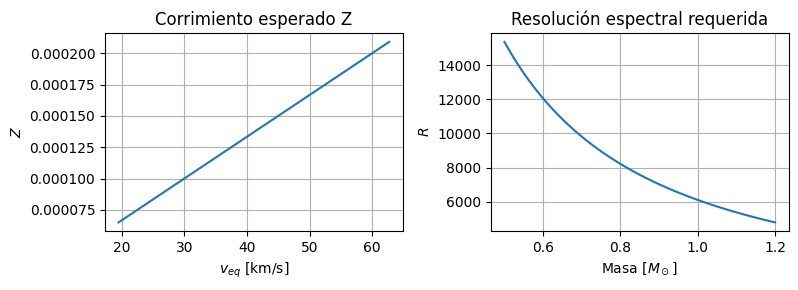

In [ ]:
# parametros y cts
G = 6.67430e-11         # Cte gravitacional [m^3 kg^-1 s^-2]
c = 3.0e8               # Velocidad de la luz [m/s]
M_sun = 1.989e30        # Masa solar [kg]
lambda_H_alpha = 656.3  # Longitud de onda de H_alpha [nm]


# Caracteristicas Enanas Blancas (WD)
ms = np.linspace(0.5, 1.2, 100)*M_sun  # Masa [kg]
R_WD = 9e6 * (ms / M_sun)**(-1/3)      # Radio [m]
v_e = (2*G*ms / R_WD)**.5              # Velocidad escape[m/s]

# corrimiento espectral (asumiendo obs asintotico v_e2=0)
z = (1-(v_e/c)**2)**-.5 - 1

v_eq = c * z  # Velocidad radial equivalente
R = 1 / z     # Resolución espectral R

# Grafico corrimiento espectral vs masa
fig, ax  = plt.subplots(1,2,figsize=(8, 3))
ax[0].plot(v_eq/1e3, z)
ax[0].set_title('Corrimiento esperado Z')
ax[0].set_xlabel(r'$v_{eq}$ [km/s]')
ax[0].set_ylabel(r'$Z$')
ax[0].grid()

# Grafico resolución espectral vs masa
ax[1].plot(ms/M_sun, R)
ax[1].set_title('Resolución espectral requerida')
ax[1].set_xlabel('Masa [$M_\odot$]')
ax[1].set_ylabel('$R$')
ax[1].grid()
fig.tight_layout()

"La resolución espectral indica qué tan bien puede un espectrómetro distinguir cambios en la longitud de onda. Un valor alto de $R$ implica que puede detectar corrimientos muy pequeños" - *Recuperado de chat-gpt.*

**Estimacion masa Sirio b**

Se tiene el rango de velocidades equivalentes para sirio b, y consecuentemente el valor del corrimiento $z=v_{\text{eq}}/c$, ahora la velocidad de escape se puede despejar de ecuacion del corrimiento $z  = \frac{1}{\sqrt{1-v_e^2/c^2}} - 1$, de lo que resulta:


$$ v_{e} = c \sqrt{1 - \frac{1}{(z+1)^2}} $$

Finalmente con la velocidad de escape, usando la definicion de la misma se puede despejar la masa, donde quedaria como incognita faltante el radio asociado a sirio b; Para este radio se puede usar la ecuacion para el radio de las enanas blancas previamente empleada, de donde finalmente se puede despejar la masa.

$$M  =  r \ v_e^2 / 2G$$

$$M  = 9 \times 10^6 (\frac{M}{M_{\odot}})^{-1/3} \ v_e^2 / 2G$$

$$M^{4/3}  =  9 \times 10^6 \frac{v_e^2}{2G M_{\odot}^{-1/3}} $$





In [ ]:
# Datos Sirio B
v_eq_sb = np.array([80.42 - 4.83,80.42, 80.42+ 4.83])*1e3 # vel equiv [m/s]
z_sb = v_eq_sb / c                                        # corrimiento
v_e_sb = c*( 1 - 1/(1 + z_sb)**2 )**.5                    # vel escape [m/s]
m_sb = (9e6*v_e_sb**2 /(2*G*(M_sun**(-1/3))))**(3/4)/M_sun # masa sirio B [M_sun]

print('rango de masas aprox sirio B:', m_sb)

rango de masas aprox sirio B: [1.38028133 1.44588763 1.51051283]


Estas medidas pueden ser una buena primera aproximacion, aunque sobreestiman un poco el valor de la literatura $1.018±0.011 M_⊙ $ *(2017, H. Bond)*, pues puede que existan modelos mas adecuados para aproximar por ejemplo la relacion masa-radio, y tambien los valores del corrimiento z.<br><br>

___

  c. Una de las [confirmaciones recientes de la teoría de la relatividad general](https://www.science.org/doi/10.1126/science.aav8137) es la observación del corrimiento gravitacional de las líneas espectrales de estrellas que orbitan el agujero negro del centro de la Vía Láctea ($M = 4\times 10^6$). Grafique el valor del corrimiento espectral gravitacional (medido en velocidad radial equivalente) sufrido por la luz de una estrella que se mueve en un órbita elíptica con parámetros e = 0.89, a = 10 au. Además del corrimiento gravitacional hay un corrimiento espectral debido a la velocidad de la estrella (efecto Doppler relativista). Asumiendo la fórmula para el corrimiento perpendicular, grafique el valor de este corrimiento independientemente y compárelo con el corrimiento gravitacional.
  
  **NOTA**: Naturalmente ambos efectos, el corrimiento Doppler relativista y el corrimiento gravitacional, no son independientes, pero en este problema los tratamos de esta manera para simplificar.



  <br>

**El corrimiento gravitacional** necesita de la velocidad de escape en algun punto de la orbita, para la que se requiere conocer el radio asociado, y con el fin de encontrarlo, se empleará la formula del radio en una órbita elíptica (con parametros orbitales $a, e, \theta$ son el semieje mayor, exentricidad y la anomalía verdadera de la órbita respectivamente)

$$r = \frac{a (1 - e^2)}{1 + e \cos\theta}$$


**El corrimiento Doppler relativista** para un movimiento perpendicular esta dado por $z_{\text{Doppler}} = \gamma - 1$ donde el factor de Lorentz se define (usando la velocidad orbital de la estrella) como $\gamma = \frac{1}{\sqrt{1 - v_\text{orb}^2 / c^2}}$.  y la velocidad orbital se puede obtener como:

$$v_\mathrm{orb} = \sqrt{G M \left(\frac{2}{r} - \frac{1}{a}\right)}$$


**Para el grafico** se variará el angulo orbital o anomalia verdadera $\theta$ en el rango [$0, 2\pi$] y posteriormente de obtener el corrimiento z con las formulas vistas previamente, se calculara el corrimiento en terminos de la la velocidad radial equivalente $v_\mathrm{eq} = c z$

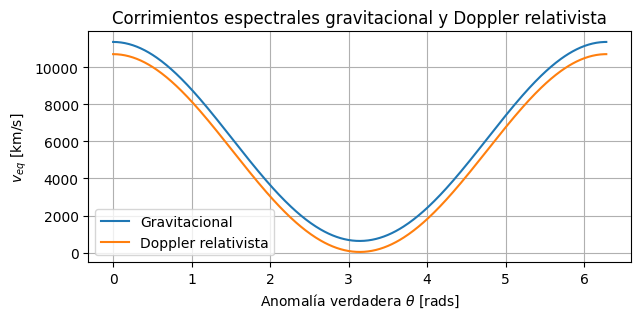

In [ ]:
# parametros agujero negro y cts
M_BH = 4e6 * M_sun  # Masa sga* [kg]
AU = 1.496e11       # [m]
a = 10*AU           # Semieje mayor [m]
e = 0.89            # Excentricidad

# caracteristicas sobre la orbita
theta = np.linspace(0, 2*np.pi, 500)   # anomalía verdadera
r = a*(1 - e**2)/(1 + e*np.cos(theta)) # Radio
v_orb = (G*M_BH*(2/r - 1/a))**.5       # Vel orbital


# Corrimiento gravitacional
v_escape = (2*G*M_BH / r)**.5           # vel de escape
z_grav = (1 - (v_escape/c)**2)**-.5 - 1 # Corrimiento gravitacional
v_eq_grav = c*z_grav                    # Vel radial equivalente

# Corrimiento Doppler relativista (perpendicular)
gamma = 1 / (1 - (v_orb/c)**2)**.5 # factor lorentz
z_doppler = gamma - 1              # corrimiento doppler
v_eq_doppler = c*z_doppler         # Vel radial equivalente

# Grafica corrimientos gravitacional y Doppler
fig = plt.figure(figsize=(7, 3))
plt.plot(theta, v_eq_grav/1e3, label="Gravitacional")
plt.plot(theta, v_eq_doppler/1e3, label="Doppler relativista")
plt.title('Corrimientos espectrales gravitacional y Doppler relativista')
plt.xlabel('Anomalía verdadera $θ$ [rads]')
plt.ylabel('$v_{eq}$ [km/s]')
plt.legend()
plt.grid()

El **corrimiento gravitacional** es mas fuerte cuando la estrella esta mas cerca del agujero negro ($\theta = 0$, periastro). y el **corrimiento Doppler relativista** tambien alcanza su máximo cerca del periastro, ya que la velocidad orbital es máxima en ese punto. Ambos difieren un poco, siendo en general mayor el corrimiento gravitacional.
<br><br>
___
<br><br><br>



2. **Geodésicas en la métrica de Newton y el principio de Hamilton**. Muestre que el postulado de las geodésicas:

   $$
   \delta\int ds = 0
   $$
   para el caso de la métrica de Newton es equivalente al principio de Hamilton:

   $$
   \delta\int Ldt = 0
   $$
   donde $L = T - U$, aplicado a una partícula puntual de masa constante sometida al potencial gravitacional clásico.

   Este resultado confirma, nuevamente, que el postulado de las geodésicas es el equivalente geométrico de la dinámica clásica.

   **Ayuda**: exprese la longitud de arco $\int ds$ como una integral en el tiempo coordenado $dt$ y haga una expansión binomial del integrando asumiendo campo débil y bajas velocidades.

3. **Covarianza de la derivada covariante**. Demuestre que la derivada covariante de un tensro de rango 1, definida como:

   $$
  A^\sigma{ }_{; \nu} \equiv {A^\sigma}_{,\nu}+\Gamma_{\mu \nu}^\sigma A^\mu
  $$
  es un tensor de rango 2. Muestre además que:

  $$
  B_{\mu ; \nu}=B_{\mu, \nu}-\Gamma_{\mu \nu}^\gamma B_\gamma
  $$

4. **Derivada covariante de tensores de rango superior**. Generalice la definición de derivada covariante para tensores de rango dos y demuestre que:
    
  $$A_{; \alpha}^{\mu \nu}=A^{\mu \nu}{ }_{, \alpha}+\Gamma_{\gamma \alpha}^\mu A^{\gamma \nu}+\Gamma_{\alpha \gamma}^\nu A^{\mu \gamma}$$

  y que

  $${{A^\mu}_\nu}_{;\alpha} = {{A^\mu}_\nu}_{,\alpha}+\Gamma_{\gamma \alpha}^\mu {A^{\gamma}}_\nu-\Gamma_{\nu\alpha}^\gamma {A^{\mu}}_\gamma$$

  Escriba una expresión general para la derivada covariante de un tensor de rango y variancia arbitraria.

5. **Propiedades básicas de la derivada covariante**. Demuestre las siguientes propiedades de la derivada covariante:

  a. *Linealidad*: $\left(A^\mu+B^\mu\right)_{;\nu}=A_{;\nu}^\mu+B_{;\nu}^\mu$

  b. *Regla de Leibniz*: $\left(A^\mu B^\nu\right)_{; \alpha}=A_{; \alpha}^\mu B^\nu+A^\mu B_{; \alpha}^\nu$

  c. *Derivada covariante de una traza*: $\left(A^\mu B_\mu\right)_{; \alpha}=\left(A^\mu B_\mu\right)_{, \alpha}$

  d. *Derivada covariante de una función escalar*: $\phi_{; \mu}=\phi_{, \mu}$.

  e. *Compatibilidad métrica*: $g_{\mu\nu;\alpha} = 0$

6. **Conservación del momentum lineal y geodésicas**. Muestre que cuando una partícula se mueve a lo largo de una geodésica su cuadrimomentum no cambia y que este resultado es independiente de si estamos o no en espacio-tiempo curvo. ¿Cómo se interpreta este resultado a la luz de la ley de inercia clásica?

**NOTA**: Algunas correcciones al enunciado pueden ser publicadas con posterioridad a la formulación del problem set. Es importante que este pendiente de la última versión de este documento antes de enviar la solución.